In [1]:
import cvxpy as cp
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns

from alphapackage.operators import *
from alphapackage.data_utils import DataHolder
from alphapackage.core import BaseAlpha, AlphaStats

from alphas import Alpha1, Alpha2, Alpha3, Alpha4, Alpha5, Alpha6, Alpha7, Alpha8, Alpha9
# from alphas import BasePortfolio
from alphas import PortfolioEqual, PortfolioSharpe, PortfolioPNL, PortfolioCorr
from alphas import MarkowitzUnconstrained, MarkowitzNonNegative, MarkowitzMinLower
from alphas import PortfolioRiskBudgetEqual, PortfolioRiskBudgetSharpe, PortfolioRiskBudgetPNL, PortfolioRiskBudgetStd

import warnings
warnings.filterwarnings("ignore")

In [2]:
dh = DataHolder(path="../csv_data", filter_outliers=False)
dh.data['return'].head()

,A,AACG,AAMI,AAOI,AAPL,AAT,ABBV,ABCB,ABEV,ABG,...,YDKG,YELP,YPF,ZBRA,ZEUS,ZG,ZTR,ZTS,ZUMZ,ZWS
Date,,,,,,,,,,,,,,,,,,,,,
2016-01-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-01-05,-0.003441,0.025118,0.008801,-0.012891,-0.025059,0.031117,-0.004166,0.003994,0.014051,-0.020896,...,-0.001795,-0.035507,-0.004430,-0.025117,-0.005968,-0.019176,0.000826,0.015655,0.009894,-0.032751
2016-01-06,0.004439,0.101072,-0.035571,-0.001866,-0.019570,-0.001032,0.000174,-0.016524,-0.011547,-0.119607,...,0.003597,-0.026672,-0.047680,-0.039957,0.000000,-0.006656,-0.009076,0.000208,-0.015023,-0.040632
2016-01-07,-0.042475,-0.116829,-0.053583,-0.047352,-0.042204,-0.021430,-0.002963,-0.018668,-0.039719,-0.029997,...,-0.010753,-0.024701,-0.016021,-0.045316,-0.057461,-0.036013,-0.011657,-0.030404,0.114721,-0.047059
2016-01-08,-0.010513,-0.070866,0.004411,-0.032701,0.005288,-0.008971,-0.027268,-0.009829,0.017031,-0.040992,...,0.000000,-0.008706,-0.006106,-0.002693,-0.032757,0.037793,-0.002527,-0.014605,-0.011303,-0.031481


## Alpha correlations

In [3]:
pnls = {}

def run_alpha(Alpha : BaseAlpha):
    global rtrns, stats

    test_alpha = Alpha()
    test_alpha.get_weights(dh)
    test_alpha.run_weights(dh)

    pnls[Alpha.__name__] = test_alpha.pnl

In [4]:
run_alpha(Alpha1)
run_alpha(Alpha2)
run_alpha(Alpha3)
run_alpha(Alpha4)
run_alpha(Alpha5)
run_alpha(Alpha6)
run_alpha(Alpha7)
run_alpha(Alpha8)
run_alpha(Alpha9)

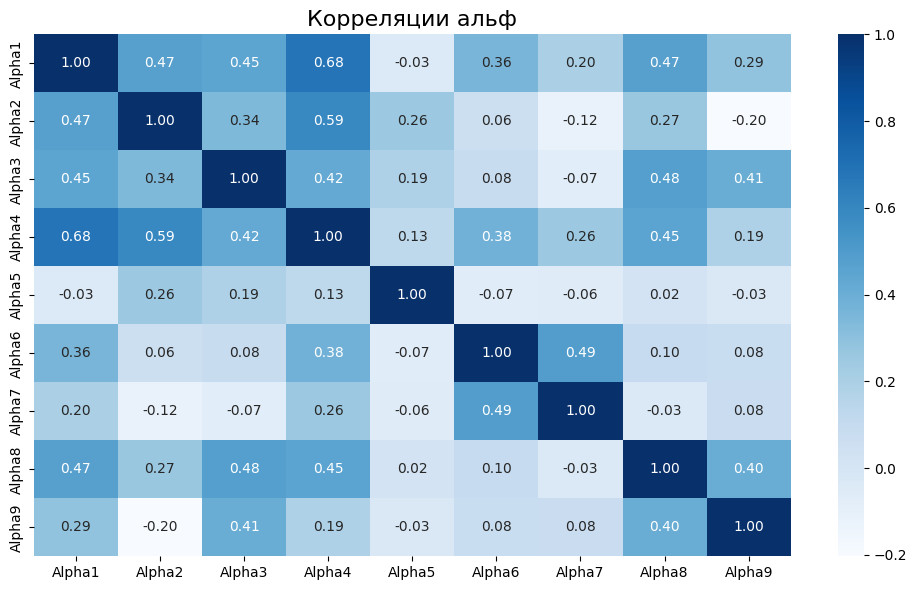

In [5]:
df = pd.DataFrame(pnls)
correlation_matrix = df.corr()

plt.figure(figsize=(10, 6))
sns.heatmap(
    correlation_matrix,
    cmap='Blues',
    annot=True,
    fmt='.2f'
)
plt.title('Корреляции альф', fontsize=16)
plt.tight_layout()
plt.show()

## CVXPY portfolio optimization dummy test

In [4]:
pd.Series(np.array([1, 2]), index=["name1", "name2"])

name1    1
name2    2
dtype: int64

In [5]:
x = cp.Variable(9)

# C = correlation_matrix.to_numpy()
# R = np.array([pnl.mean() for pnl in pnls.values()])

# testing
C = np.diag(np.ones(9))
R = np.linspace(1, 9, num = 9) # + [-4]

objective = cp.Minimize(cp.quad_form(x, C))

constraints = [
    R.T @ x == 1, # обязательное условие
    x >= 0        # дополнительное ограничение
]
problem = cp.Problem(objective, constraints)

result = problem.solve()
print(x.value)

[0.00350877 0.00701754 0.01052632 0.01403509 0.01754386 0.02105263
 0.0245614  0.02807018 0.03157895]


In [6]:
np.array(x.value) / R # same values == result is (lambda * R)

array([0.00350877, 0.00350877, 0.00350877, 0.00350877, 0.00350877,
       0.00350877, 0.00350877, 0.00350877, 0.00350877])

In [7]:
df = pd.DataFrame(np.array(x.value))

df.div(df.abs().sum())

,0
0,0.022222
1,0.044444
2,0.066667
3,0.088889
4,0.111111
5,0.133333
6,0.155556
7,0.177778
8,0.200000


In [6]:
del pnls

## Alphas initialization

In [3]:
alpha1 = Alpha1()
alpha1.get_weights(dh)
alpha1.run_weights(dh)

alpha2 = Alpha2()
alpha2.get_weights(dh)
alpha2.run_weights(dh)

alpha3 = Alpha3()
alpha3.get_weights(dh)
alpha3.run_weights(dh)

alpha5 = Alpha5()
alpha5.get_weights(dh)
alpha5.run_weights(dh)

alpha6 = Alpha6()
alpha6.get_weights(dh)
alpha6.run_weights(dh)

alpha7 = Alpha7()
alpha7.get_weights(dh)
alpha7.run_weights(dh)

alpha4 = Alpha4()
alpha4.get_weights(dh)
alpha4.run_weights(dh)

alpha8 = Alpha8()
alpha8.get_weights(dh)
alpha8.run_weights(dh)

alpha9 = Alpha9()
alpha9.get_weights(dh)
alpha9.run_weights(dh)

In [4]:
alphas = {
    "alpha1": alpha1,
    "alpha2": alpha2,
    "alpha3": alpha3,
    "alpha5": alpha5,
    "alpha6": alpha6,
    "alpha7": alpha7,
    "alpha4": alpha4,
    "alpha8": alpha8,
    "alpha9": alpha9
}

## Heuristic portfolios

In [5]:
portf_equal = PortfolioEqual(alphas, 'Y')

portf_equal.get_weights(dh)
portf_equal.run_weights(dh)

stats_equal = AlphaStats(portf_equal)

In [6]:
portf_equal.alpha_weights_rebalance

,alpha1,alpha2,alpha3,alpha5,alpha6,alpha7,alpha4,alpha8,alpha9
2016-01-04,0.111111,0.111111,0.111111,0.111111,0.111111,0.111111,0.111111,0.111111,0.111111
2016-12-30,0.111111,0.111111,0.111111,0.111111,0.111111,0.111111,0.111111,0.111111,0.111111
2017-12-29,0.111111,0.111111,0.111111,0.111111,0.111111,0.111111,0.111111,0.111111,0.111111
2018-12-31,0.111111,0.111111,0.111111,0.111111,0.111111,0.111111,0.111111,0.111111,0.111111
2019-12-31,0.111111,0.111111,0.111111,0.111111,0.111111,0.111111,0.111111,0.111111,0.111111
2020-12-31,0.111111,0.111111,0.111111,0.111111,0.111111,0.111111,0.111111,0.111111,0.111111
2021-12-31,0.111111,0.111111,0.111111,0.111111,0.111111,0.111111,0.111111,0.111111,0.111111


In [7]:
portf_sharpe = PortfolioSharpe(alphas)

portf_sharpe.get_weights(dh)
portf_sharpe.run_weights(dh)

stats_sharpe = AlphaStats(portf_sharpe)

In [8]:
portf_sharpe.alpha_weights_rebalance

,alpha1,alpha2,alpha3,alpha5,alpha6,alpha7,alpha4,alpha8,alpha9
2016-01-04,0.111111,0.111111,0.111111,0.111111,0.111111,0.111111,0.111111,0.111111,0.111111
2016-04-01,0.124771,0.065852,0.139039,-0.062965,0.139794,0.094575,0.238816,0.000000,0.134188
2016-07-01,0.119663,0.127197,0.054138,0.005402,0.127413,0.197839,0.245398,-0.047038,0.075912
2016-09-30,0.105203,0.129305,0.060534,0.052303,0.121919,0.140329,0.276720,0.066003,-0.047682
2016-12-30,0.039746,0.032833,-0.001585,0.083947,0.138419,0.216052,0.172722,0.102781,0.211916
2017-03-31,0.070968,0.121434,0.081799,0.055565,0.136361,0.054805,0.287623,0.148388,-0.043058
2017-06-30,0.104423,0.026322,0.085071,0.129650,0.094888,0.163049,0.224311,0.065392,0.106893
2017-09-29,0.190401,0.097058,0.033578,0.036574,0.146528,0.153923,0.297001,0.035800,-0.009138
2017-12-29,0.112400,0.079532,0.005005,0.201755,0.077040,0.172165,0.279014,-0.057745,0.015343
2018-03-29,0.134450,0.066071,-0.103314,0.115095,0.185524,0.132173,0.182030,0.030332,0.051010


In [9]:
portf_pnl = PortfolioPNL(alphas)

portf_pnl.get_weights(dh)
portf_pnl.run_weights(dh)

stats_pnl = AlphaStats(portf_pnl)

In [10]:
portf_pnl.alpha_weights_rebalance

,alpha1,alpha2,alpha3,alpha5,alpha6,alpha7,alpha4,alpha8,alpha9
2016-01-04,0.111111,0.111111,0.111111,0.111111,0.111111,0.111111,0.111111,0.111111,0.111111
2016-04-01,0.227758,0.165937,0.251090,-0.010801,0.079651,0.043543,0.158079,0.000000,0.063142
2016-07-01,0.247928,0.196921,0.165285,-0.003226,0.105624,0.058190,0.155853,-0.007668,0.059305
2016-09-30,0.224644,0.212910,0.176471,0.007279,0.115140,0.059823,0.148399,0.028989,0.026344
2016-12-30,0.209826,0.203099,0.158941,0.011874,0.125738,0.065899,0.148475,0.037668,0.038479
2017-03-31,0.187349,0.217600,0.118720,0.021485,0.139079,0.062043,0.151440,0.086871,0.015413
2017-06-30,0.163605,0.183346,0.135501,0.034894,0.133911,0.060848,0.150489,0.124990,0.012415
2017-09-29,0.188714,0.153219,0.083348,0.035506,0.147340,0.062742,0.176174,0.124889,0.028068
2017-12-29,0.217645,0.178466,0.084425,0.046733,0.125614,0.063593,0.191834,0.082131,0.009559
2018-03-29,0.273220,0.151368,0.006628,0.062260,0.145115,0.084851,0.199011,0.038842,0.038706


In [11]:
portf_corr = PortfolioCorr(alphas)

portf_corr.get_weights(dh)
portf_corr.run_weights(dh)

stats_corr = AlphaStats(portf_corr)

In [12]:
portf_corr.alpha_weights_rebalance

,alpha1,alpha2,alpha3,alpha5,alpha6,alpha7,alpha4,alpha8,alpha9
2016-01-04,0.111111,0.111111,0.111111,0.111111,0.111111,0.111111,0.111111,0.111111,0.111111
2016-02-01,0.251007,0.282344,0.108794,0.000000,0.000000,0.002962,0.283465,0.000000,0.071428
2016-03-01,0.227129,0.221223,0.127425,0.000000,0.000000,-0.079641,0.232813,0.000000,0.111769
2016-04-01,0.240101,0.139645,0.120520,-0.072152,0.047482,0.028315,0.256733,0.000000,0.095052
2016-04-29,0.233398,0.138451,0.091906,-0.055632,0.104909,0.033446,0.251250,0.000000,0.091008
...,...,...,...,...,...,...,...,...,...
2021-07-30,0.181304,0.103830,0.144842,0.022761,0.090523,0.047022,0.195938,0.134925,0.078855
2021-09-01,0.181020,0.104113,0.144579,0.023428,0.091067,0.046263,0.195825,0.135026,0.078678
2021-10-01,0.181098,0.103379,0.144633,0.023607,0.091426,0.046391,0.195784,0.135019,0.078664
2021-11-01,0.181215,0.103490,0.144604,0.023679,0.091465,0.046368,0.195925,0.135076,0.078178


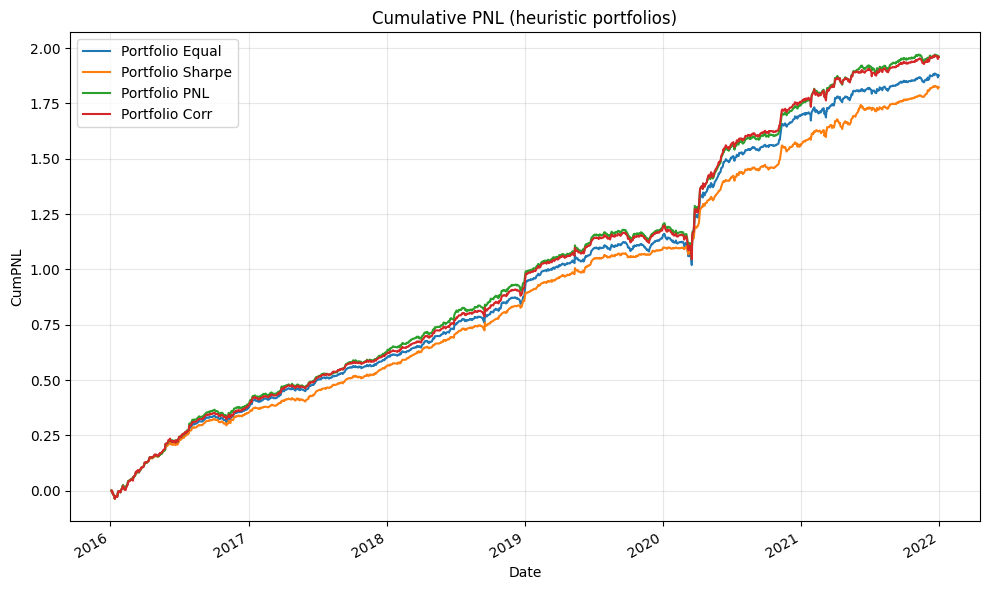

In [13]:
df = pd.DataFrame({
    'Portfolio Equal': portf_equal.cumpnl,
    'Portfolio Sharpe': portf_sharpe.cumpnl,
    'Portfolio PNL': portf_pnl.cumpnl,
    'Portfolio Corr': portf_corr.cumpnl
})

df.plot(figsize=(10, 6), title='Cumulative PNL (heuristic portfolios)')
plt.xlabel('Date')
plt.ylabel('CumPNL')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#### Portfolio Equal

In [14]:
stats_equal.print_average_stats()

****************************************
average_turnover = 0.5944174164081735
average_Sharpe = 3.8300308242485843
sum_pnl = 1.8763282047566394
****************************************


In [15]:
stats_pnl.corr_with(portf_sharpe)

np.float64(0.8936068136457177)

#### Portfolio Sharpe

In [16]:
stats_sharpe.print_average_stats()

****************************************
average_turnover = 0.6717985857342685
average_Sharpe = 4.6758170663050045
sum_pnl = 1.8234658760324964
****************************************


#### Portfolio PNL

In [17]:
stats_pnl.print_average_stats()

****************************************
average_turnover = 0.6134961108122382
average_Sharpe = 3.8065544525250363
sum_pnl = 1.9628935990440688
****************************************


#### Portfolio Correlations

In [18]:
stats_corr.print_average_stats()

****************************************
average_turnover = 0.6165442899277493
average_Sharpe = 3.927827766348504
sum_pnl = 1.9591032434751414
****************************************


## Markowitz portfolios

In [19]:
markowitz_uc = MarkowitzUnconstrained(alphas)

markowitz_uc.get_weights(dh)
markowitz_uc.run_weights(dh)

stats_uc = AlphaStats(markowitz_uc)

In [20]:
markowitz_uc.alpha_weights_rebalance

,alpha1,alpha2,alpha3,alpha5,alpha6,alpha7,alpha4,alpha8,alpha9
2016-01-04,0.111111,0.111111,0.111111,0.111111,0.111111,0.111111,0.111111,0.111111,0.111111
2016-04-01,203.239520,82.680987,279.211508,5.607969,70.350688,90.436853,-48.112320,-0.000000,-26.962994
2016-07-01,302.431645,289.546435,123.697346,-29.837951,64.944487,141.903057,-198.425502,-41.225489,-39.741325
2016-09-30,242.774260,324.091651,133.325936,-48.494469,62.010883,164.556414,-228.511643,-11.936351,-42.948481
2016-12-30,266.387584,388.127301,167.086486,-50.581402,129.515919,155.513539,-213.431533,-71.438027,41.845484
2017-03-31,256.072327,509.714741,65.606831,-57.542096,114.981816,88.309154,-177.550912,18.642057,101.829105
2017-06-30,335.996018,611.488498,138.144851,59.574788,156.676608,28.900722,-178.646051,14.322399,226.399973
2017-09-29,509.378639,602.468446,-192.419635,152.564336,219.224644,-207.795212,91.328624,78.305391,389.402888
2017-12-29,513.100049,430.716154,-67.601969,200.047041,-23.587156,-32.970663,206.019366,-22.603108,262.716181
2018-03-29,633.456251,193.678572,-269.839941,186.206849,114.514598,-56.373280,121.228944,23.477649,150.163076


In [21]:
markowitz_nn = MarkowitzNonNegative(alphas)

markowitz_nn.get_weights(dh)
markowitz_nn.run_weights(dh)

stats_nn = AlphaStats(markowitz_nn)

In [22]:
markowitz_nn.alpha_weights_rebalance

,alpha1,alpha2,alpha3,alpha5,alpha6,alpha7,alpha4,alpha8,alpha9
2016-01-04,1.111111e-01,1.111111e-01,1.111111e-01,1.111111e-01,1.111111e-01,1.111111e-01,1.111111e-01,1.111111e-01,1.111111e-01
2016-04-01,1.869427e+02,5.410907e+01,2.797657e+02,8.247230e+00,6.685703e+01,7.464614e+01,-6.045563e-20,-0.000000e+00,1.910207e-20
2016-07-01,2.490536e+02,2.076774e+02,1.320660e+02,-3.649175e-21,2.847471e+01,1.239397e+02,8.325103e-20,-1.040674e-20,4.707769e-20
2016-09-30,1.926439e+02,2.253803e+02,1.480662e+02,3.276023e-24,3.163314e+01,1.216512e+02,-6.909702e-20,-2.414983e-20,1.517220e-20
2016-12-30,2.350087e+02,2.920133e+02,1.664462e+02,-1.384882e-20,9.548682e+01,9.906722e+01,5.915711e-20,-3.091261e-20,2.168465e+01
2017-03-31,2.421559e+02,4.369090e+02,5.408108e+01,7.175632e-20,8.508105e+01,3.243922e+01,1.416330e-19,6.775733e+00,1.244882e+02
2017-06-30,3.055865e+02,5.392089e+02,1.367300e+02,4.813841e+01,1.233841e+02,-2.771322e-22,-5.629205e-20,-2.458741e-21,2.216236e+02
2017-09-29,4.808182e+02,6.091964e+02,-5.642903e-20,1.051979e+02,2.186484e+02,1.253189e-20,2.037365e+01,1.305611e+01,3.074448e+02
2017-12-29,4.966182e+02,4.377874e+02,-5.616036e-20,1.870398e+02,1.003178e-19,3.398664e-20,1.573067e+02,-9.239317e-21,2.265775e+02
2018-03-29,6.553879e+02,1.867414e+02,-8.154417e-22,1.802131e+02,1.090758e+02,2.248834e-20,8.640835e+01,-1.909586e-20,8.532004e+01


In [23]:
markowitz_lb = MarkowitzMinLower(alphas)

markowitz_lb.get_weights(dh)
markowitz_lb.run_weights(dh)

stats_lb = AlphaStats(markowitz_lb)

In [24]:
markowitz_lb.alpha_weights_rebalance

,alpha1,alpha2,alpha3,alpha5,alpha6,alpha7,alpha4,alpha8,alpha9
2016-01-04,0.111111,0.111111,0.111111,0.111111,0.111111,0.111111,0.111111,0.111111,0.111111
2016-04-01,169.481749,43.037014,269.854204,43.037014,69.290354,50.854871,43.037014,43.037014,43.037014
2016-07-01,246.931694,176.735255,115.890879,47.741258,47.741258,81.078528,47.741258,47.741258,47.741258
2016-09-30,171.984349,213.736633,133.268750,46.834918,46.834918,89.864196,46.834918,46.834918,46.834918
2016-12-30,234.198770,278.662359,140.510083,56.105320,73.510454,58.592808,56.105320,56.105320,56.105320
2017-03-31,237.159650,382.250201,59.051264,59.051264,59.051264,59.051264,59.051264,59.051264,89.205318
2017-06-30,277.431252,460.041051,126.778669,78.246118,78.246118,78.246118,78.246118,78.246118,152.948559
2017-09-29,438.439994,487.531544,96.879992,96.879992,170.357900,96.879992,96.879992,96.879992,163.110455
2017-12-29,452.911329,418.508683,85.296645,136.089184,85.296645,85.296645,85.296645,85.296645,101.347183
2018-03-29,632.050536,203.323997,82.064579,149.400411,82.064579,82.064579,82.064579,82.064579,82.064579


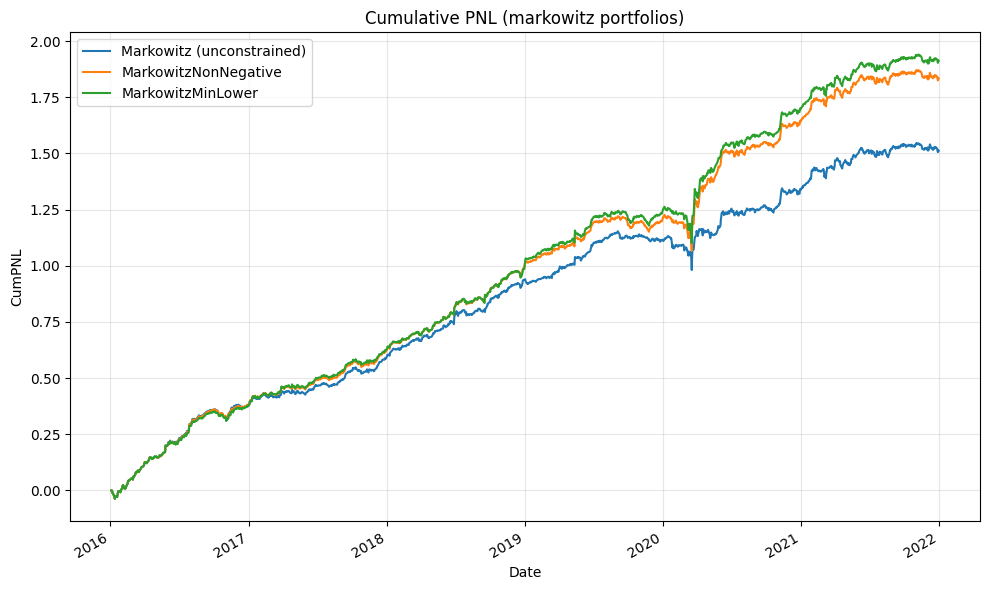

In [25]:
df = pd.DataFrame({
    "Markowitz (unconstrained)": markowitz_uc.cumpnl,
    "MarkowitzNonNegative": markowitz_nn.cumpnl,
    "MarkowitzMinLower": markowitz_lb.cumpnl
})

df.plot(figsize=(10, 6), title='Cumulative PNL (markowitz portfolios)')
plt.xlabel('Date')
plt.ylabel('CumPNL')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Markowitz Unconstrained

In [26]:
stats_uc.print_average_stats()

****************************************
average_turnover = 0.558699423076832
average_Sharpe = 2.9740611942024207
sum_pnl = 1.5119585997502698
****************************************


### Markowitz Non negative

In [27]:
stats_nn.print_average_stats()

****************************************
average_turnover = 0.5676627376812452
average_Sharpe = 3.3313488756736813
sum_pnl = 1.833283895998803
****************************************


### Markowitz Lower bound

In [28]:
stats_lb.print_average_stats()

****************************************
average_turnover = 0.5834863798956262
average_Sharpe = 3.439601395847222
sum_pnl = 1.911818458212866
****************************************


## Risk budgeting portfolios

In [29]:
rb_equal = PortfolioRiskBudgetEqual(alphas)

rb_equal.get_weights(dh)
rb_equal.run_weights(dh)

stats_rbe = AlphaStats(rb_equal)

In [30]:
rb_equal.alpha_weights_rebalance

,alpha1,alpha2,alpha3,alpha5,alpha6,alpha7,alpha4,alpha8,alpha9
2016-01-04,0.111111,0.111111,0.111111,0.111111,0.111111,0.111111,0.111111,0.111111,0.111111
2016-04-01,0.099228,0.106495,0.107144,0.122077,0.112797,0.113526,0.098229,0.131749,0.108756
2016-07-01,0.100674,0.110081,0.112401,0.120966,0.109165,0.124508,0.100074,0.111085,0.111045
2016-09-30,0.101358,0.110619,0.111232,0.119960,0.106799,0.118731,0.099861,0.115699,0.115741
2016-12-30,0.103133,0.112967,0.111761,0.120627,0.107690,0.114266,0.099602,0.112441,0.117513
2017-03-31,0.104402,0.114532,0.110150,0.120074,0.105568,0.112353,0.099923,0.109534,0.123464
2017-06-30,0.106394,0.116906,0.109638,0.123641,0.105154,0.109274,0.098812,0.105478,0.124706
2017-09-29,0.106891,0.119233,0.105562,0.126052,0.106212,0.109165,0.099620,0.103199,0.124066
2017-12-29,0.104927,0.118389,0.104330,0.127832,0.103724,0.111160,0.100487,0.104393,0.124759
2018-03-29,0.104535,0.120332,0.108147,0.123203,0.104121,0.110561,0.100136,0.110333,0.118632


In [31]:
rb_sharpe = PortfolioRiskBudgetSharpe(alphas)

rb_sharpe.get_weights(dh)
rb_sharpe.run_weights(dh)

stats_rbs = AlphaStats(rb_sharpe)

In [48]:
rb_sharpe.alpha_weights_rebalance

,alpha1,alpha2,alpha3,alpha5,alpha6,alpha7,alpha4,alpha8,alpha9
2016-01-04,0.111111,1.111111e-01,1.111111e-01,1.111111e-01,1.111111e-01,1.111111e-01,0.111111,1.111111e-01,1.111111e-01
2016-04-01,0.121978,7.243515e-02,1.563269e-01,1.000000e-12,1.567987e-01,1.170378e-01,0.226345,1.000000e-12,1.490932e-01
2016-07-01,0.112047,1.425422e-01,6.594348e-02,8.268946e-03,1.257192e-01,2.276558e-01,0.225571,2.066412e-05,9.223139e-02
2016-09-30,0.125872,1.322637e-01,7.565718e-02,6.044113e-02,1.205817e-01,1.528296e-01,0.244826,8.748037e-02,4.849472e-05
2016-12-30,0.040462,4.555416e-02,1.319844e-05,1.041765e-01,1.380832e-01,1.930401e-01,0.157616,1.064467e-01,2.146081e-01
2017-03-31,0.081686,1.284090e-01,8.512072e-02,7.812301e-02,1.394329e-01,8.068091e-02,0.258340,1.481939e-01,1.359458e-05
2017-06-30,0.100780,3.164833e-02,8.871822e-02,1.721236e-01,8.745279e-02,1.573964e-01,0.190623,6.258935e-02,1.086690e-01
2017-09-29,0.182222,1.129660e-01,4.046386e-02,5.419836e-02,1.470438e-01,1.545534e-01,0.263668,4.488174e-02,2.870974e-06
2017-12-29,0.120598,8.477033e-02,6.889531e-03,2.253595e-01,8.472803e-02,1.874696e-01,0.260312,2.530367e-05,2.984723e-02
2018-03-29,0.147391,8.545535e-02,6.028348e-06,1.285570e-01,1.912111e-01,1.502565e-01,0.180643,4.799171e-02,6.848889e-02


In [32]:
rb_pnl = PortfolioRiskBudgetPNL(alphas)

rb_pnl.get_weights(dh)
rb_pnl.run_weights(dh)

stats_rbp = AlphaStats(rb_pnl)

In [49]:
rb_pnl.alpha_weights_rebalance

,alpha1,alpha2,alpha3,alpha5,alpha6,alpha7,alpha4,alpha8,alpha9
2016-01-04,0.111111,1.111111e-01,0.111111,1.111111e-01,0.111111,0.111111,0.111111,1.111111e-01,1.111111e-01
2016-04-01,0.209865,1.597111e-01,0.246905,1.000000e-12,0.098762,0.063630,0.145489,1.000000e-12,7.563987e-02
2016-07-01,0.244084,2.249214e-01,0.100552,4.162398e-03,0.118325,0.099757,0.140283,3.308520e-05,6.788189e-02
2016-09-30,0.177204,2.166577e-01,0.181619,2.850401e-02,0.118651,0.070288,0.112123,9.497978e-02,1.000000e-12
2016-12-30,0.076893,1.061434e-01,0.000003,6.275946e-02,0.209061,0.108634,0.134464,1.323016e-01,1.697409e-01
2017-03-31,0.146354,2.236407e-01,0.109961,3.558473e-02,0.120077,0.034039,0.152531,1.777633e-01,4.990667e-05
2017-06-30,0.199299,6.654964e-02,0.138636,1.020485e-01,0.098515,0.083368,0.135226,9.661366e-02,7.974399e-02
2017-09-29,0.253917,1.741286e-01,0.052975,2.582560e-02,0.168460,0.071266,0.185854,6.757131e-02,2.832388e-06
2017-12-29,0.212864,2.262074e-01,0.010756,1.247687e-01,0.081946,0.118748,0.195660,7.879756e-05,2.897085e-02
2018-03-29,0.229078,1.741421e-01,0.000002,7.755861e-02,0.167853,0.081193,0.149809,6.374577e-02,5.661971e-02


In [33]:
rb_std = PortfolioRiskBudgetStd(alphas)

rb_std.get_weights(dh)
rb_std.run_weights(dh)

stats_rbstd = AlphaStats(rb_std)

In [50]:
rb_std.alpha_weights_rebalance

,alpha1,alpha2,alpha3,alpha5,alpha6,alpha7,alpha4,alpha8,alpha9
2016-01-04,0.111111,0.111111,0.111111,0.111111,0.111111,0.111111,0.111111,0.111111,0.111111
2016-04-01,0.196908,0.267816,0.204399,0.031173,0.083788,0.078913,0.070795,0.000024,0.066185
2016-07-01,0.219449,0.183722,0.177639,0.068775,0.101791,0.055933,0.062946,0.042539,0.087207
2016-09-30,0.149606,0.170640,0.254070,0.052504,0.095527,0.048845,0.041324,0.121226,0.066258
2016-12-30,0.164629,0.220554,0.118117,0.058158,0.136854,0.046483,0.067700,0.107193,0.080313
2017-03-31,0.187228,0.200162,0.128336,0.058625,0.087513,0.049555,0.057924,0.120918,0.109740
2017-06-30,0.177944,0.200929,0.144318,0.071716,0.098118,0.049640,0.055201,0.131151,0.070983
2017-09-29,0.141921,0.180160,0.129476,0.058140,0.114051,0.045676,0.067355,0.149053,0.114167
2017-12-29,0.144007,0.237060,0.121762,0.048340,0.079548,0.050333,0.059044,0.167210,0.092696
2018-03-29,0.151220,0.220917,0.124076,0.057199,0.078329,0.055317,0.075501,0.151004,0.086436


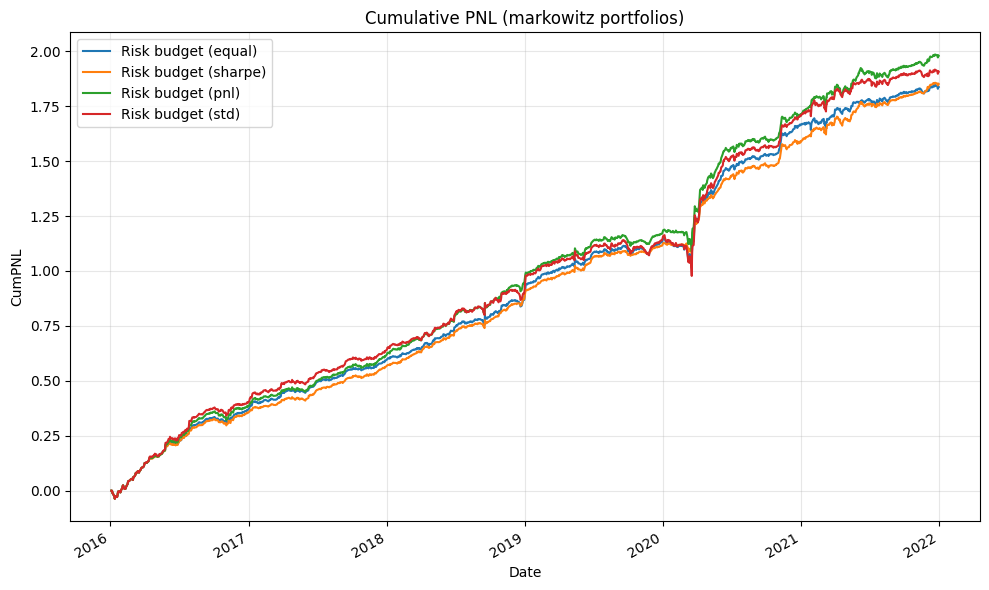

In [34]:
df = pd.DataFrame({
    "Risk budget (equal)": rb_equal.cumpnl,
    "Risk budget (sharpe)": rb_sharpe.cumpnl,
    "Risk budget (pnl)": rb_pnl.cumpnl,
    "Risk budget (std)": rb_std.cumpnl
})

df.plot(figsize=(10, 6), title='Cumulative PNL (markowitz portfolios)')
plt.xlabel('Date')
plt.ylabel('CumPNL')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Risk budget portfolio (equal)

In [32]:
stats_rbe.print_average_stats()

****************************************
average_turnover = 0.594026681938505
average_Sharpe = 3.808720565409846
sum_pnl = 1.8375987449671025
****************************************


### Risk budget portfolio (sharpe, 3 months)

In [45]:
stats_sharpe.print_average_stats()

****************************************
average_turnover = 0.6717985857342685
average_Sharpe = 4.6758170663050045
sum_pnl = 1.8234658760324964
****************************************


### Risk budget portfolio (pnl, 3 months)

In [46]:
stats_pnl.print_average_stats()

****************************************
average_turnover = 0.6134961108122382
average_Sharpe = 3.8065544525250363
sum_pnl = 1.9628935990440688
****************************************


### Risk budget portfolio (std(pnl), 3 months)

In [47]:
stats_rbstd.print_average_stats()

****************************************
average_turnover = 0.5182863823540633
average_Sharpe = 3.27879753889802
sum_pnl = 1.9064445701510881
****************************************


## All portfolios comparison

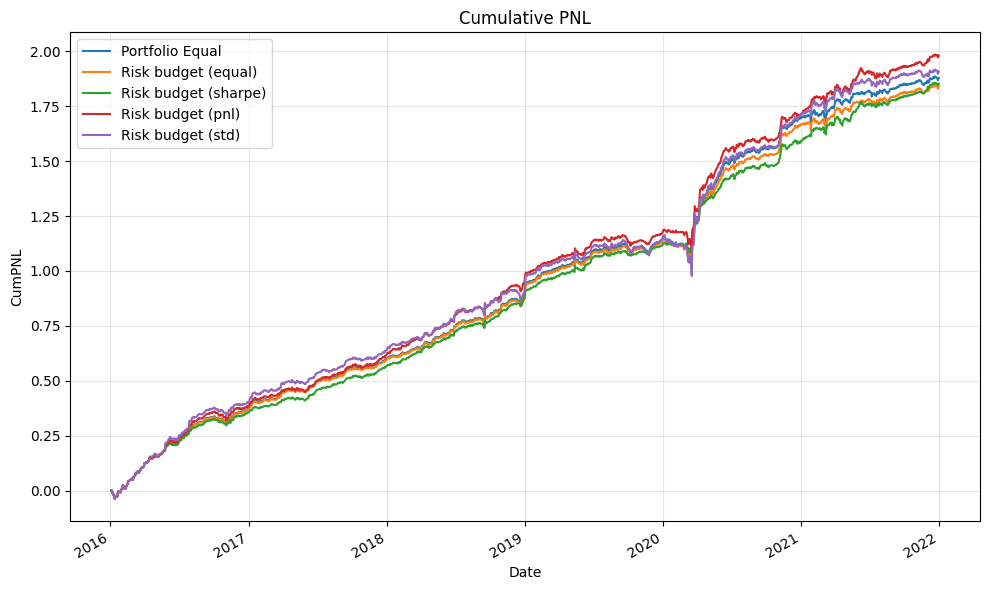

In [52]:
df = pd.DataFrame({
    # "Markowitz (unconstrained)": markowitz_uc.cumpnl,
    # "MarkowitzNonNegative": markowitz_nn.cumpnl,
    # "MarkowitzMinLower": markowitz_lb.cumpnl,
    'Portfolio Equal': portf_equal.cumpnl,
    # 'Portfolio Sharpe': portf_sharpe.cumpnl,
    # 'Portfolio PNL': portf_pnl.cumpnl,
    # 'Portfolio Corr': portf_corr.cumpnl,
    # 'Portfolio RB Equal': rb_equal.cumpnl,
    "Risk budget (equal)": rb_equal.cumpnl,
    "Risk budget (sharpe)": rb_sharpe.cumpnl,
    "Risk budget (pnl)": rb_pnl.cumpnl,
    "Risk budget (std)": rb_std.cumpnl
})

df.plot(figsize=(10, 6), title='Cumulative PNL')
plt.xlabel('Date')
plt.ylabel('CumPNL')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

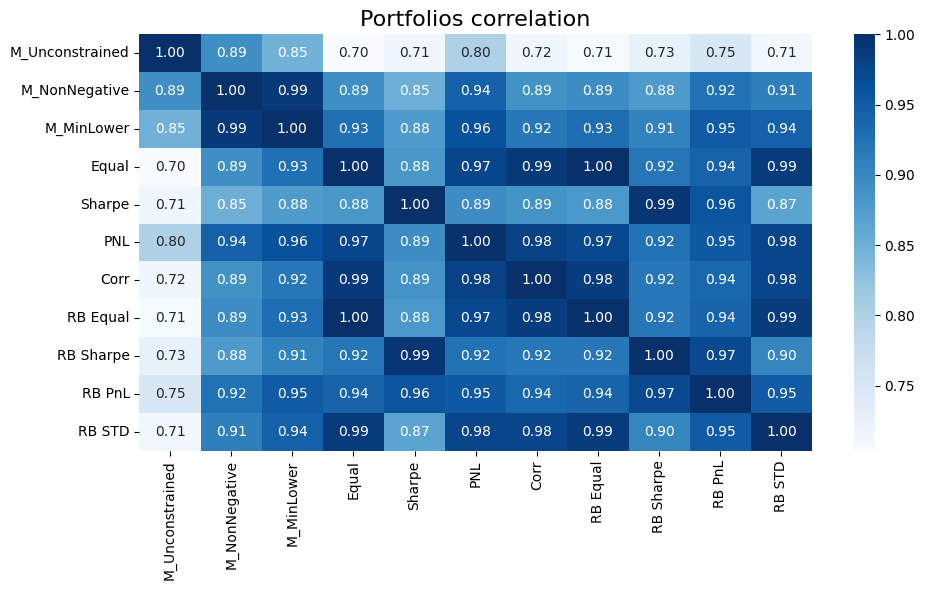

In [44]:
df = pd.DataFrame({
    "M_Unconstrained": markowitz_uc.pnl,
    "M_NonNegative": markowitz_nn.pnl,
    "M_MinLower": markowitz_lb.pnl,
    'Equal': portf_equal.pnl,
    'Sharpe': portf_sharpe.pnl,
    'PNL': portf_pnl.pnl,
    'Corr': portf_corr.pnl,
    'RB Equal': rb_equal.pnl,
    'RB Sharpe': rb_sharpe.pnl,
    'RB PnL': rb_pnl.pnl,
    'RB STD': rb_std.pnl
})

correlation_matrix = df.corr()

plt.figure(figsize=(10, 6))
sns.heatmap(
    correlation_matrix,
    cmap='Blues',
    annot=True,
    fmt='.2f'
)
plt.title("Portfolios correlation", fontsize=16)
plt.tight_layout()
plt.show()